In [1]:
import polars as pl

df1 = pl.read_csv("plsDS_soc455055_fr2_1RC_R0free_main.csv")
#df2 = pl.read_csv("plsDS_soc455055_fr2_2RC_R0free_main.csv")

df1 = df1.select(pl.col("R0"),
                 pl.col("R1"),
                 pl.col("R2"),
                 pl.col("name"),
                 pl.col("tau1"),
                 pl.col("tau2"),
                )
display(df1.tail(3))

R0,R1,R2,name,tau1,tau2
f64,f64,f64,str,f64,i64
0.035879,0.016251,0.002251,"""soc55_2Cchr_9sec""",36.455614,100
0.036309,0.014576,0.003305,"""soc55_2Cchr_18sec""",37.055538,100
0.035671,0.014435,0.002113,"""soc55_3Cchr_9sec""",32.288006,100


In [2]:
import os
import glob

folder_path = r"/content/plsDS_soc455055_fr2_1RC_R0free_pls_tables"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

mp = {
    os.path.splitext(os.path.basename(file))[0]: pl.read_csv(file)
    for file in csv_files
}
for key in mp:
    mp[key] = mp[key].drop("Step").drop("Q")


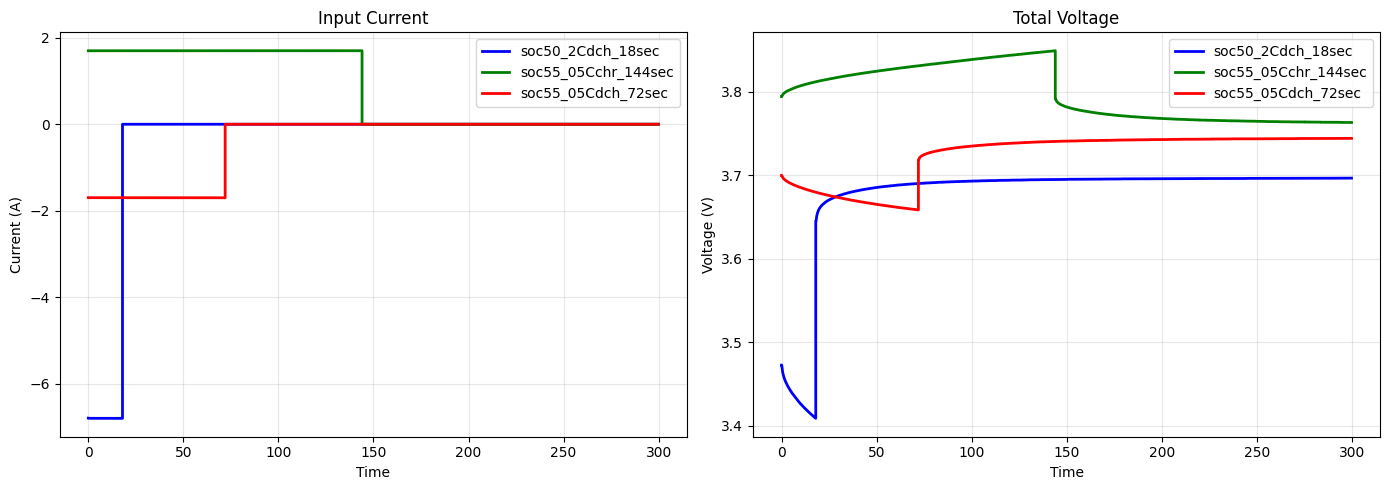

In [3]:
import matplotlib.pyplot as plt

model_names = list(mp.keys())[:3]

time_col = "Time"
current_col = "I"
voltage_col = "E"

colors = ["blue", "green", "red"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График тока
for model_name, color in zip(model_names, colors):
    df = mp[model_name]

    axes[0].plot(
        df[time_col].to_list()[:3000],
        df[current_col].to_list()[:3000],
        label=model_name,
        color=color,
        linewidth=2
    )

axes[0].set_title("Input Current")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Current (A)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# График напряжения
for model_name, color in zip(model_names, colors):
    df = mp[model_name]

    axes[1].plot(
        df[time_col].to_list()[:3000],
        df[voltage_col].to_list()[:3000],
        label=model_name,
        color=color,
        linewidth=2
    )

axes[1].set_title("Total Voltage")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Voltage (V)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
import random

random.seed(42)

model_names = list(mp.keys())
random.shuffle(model_names)

split_idx = int(0.8 * len(model_names))

train_keys = model_names[:split_idx]
val_keys = model_names[split_idx:]

train_data = {key: mp[key] for key in train_keys}
val_data = {key: mp[key] for key in val_keys}

print(f"Всего моделей: {len(model_names)}")
print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")

Всего моделей: 72
Train: 57
Val: 15


In [5]:
import torch
import torch.nn as nn


class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, mask=None):
        # x: (batch, seq_len, hidden_dim)
        scores = self.attn(x).squeeze(-1)  # (batch, seq_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(scores, dim=1)  # (batch, seq_len)
        pooled = torch.sum(x * weights.unsqueeze(-1), dim=1)  # (batch, hidden_dim)
        return pooled, weights


class ECMBiLSTMRegressor(nn.Module):
    def __init__(
        self,
        input_dim=2,
        hidden_dim=128,
        num_layers=2,
        lstm_dropout=0.2,
        fc_dropout=0.2,
        output_dim=5
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )

        self.attention = AttentionPooling(hidden_dim * 2)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(fc_dropout),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(fc_dropout),

            nn.Linear(64, output_dim)
        )

    def forward(self, x, mask=None):
        # x: (batch, seq_len, 2)
        x = self.input_proj(x)          # (batch, seq_len, 32)
        x, _ = self.lstm(x)             # (batch, seq_len, 2*hidden_dim)
        x, attn_weights = self.attention(x, mask=mask)
        out = self.head(x)              # (batch, 5)
        return out

In [6]:
import numpy as np

target_cols = ["R0", "R1", "R2", "tau1", "tau2"]

target_dict = {
    row["name"]: np.array([row[col] for col in target_cols], dtype=np.float64)
    for row in df1.iter_rows(named=True)
}

train_target_dict = {key: target_dict[key] for key in train_keys}
val_target_dict = {key: target_dict[key] for key in val_keys}

print(f"Всего target'ов: {len(target_dict)}")
print(f"Train target'ов: {len(train_target_dict)}")
print(f"Val target'ов: {len(val_target_dict)}")

first_key = train_keys[0]
print(first_key)
print(train_target_dict[first_key])

Всего target'ов: 72
Train target'ов: 57
Val target'ов: 15
soc45_1Cchr_36sec
[3.84759834e-02 1.41507769e-02 4.36608735e-03 4.57650797e+01
 1.00000000e+02]


In [7]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.10.0+cu128
12.8
True


In [8]:
import torch
from torch.utils.data import Dataset

class ECMDataset(Dataset):
    def __init__(self, data_dict, target_dict, keys):
        self.data_dict = data_dict
        self.target_dict = target_dict
        self.keys = keys

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]
        df = self.data_dict[key]

        x = np.stack([
            df["I"].to_numpy(),
            df["E"].to_numpy()
        ], axis=1).astype(np.float32)

        y = self.target_dict[key].astype(np.float32)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [9]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    xs, ys = zip(*batch)

    lengths = torch.tensor([x.size(0) for x in xs], dtype=torch.long)
    x_padded = pad_sequence(xs, batch_first=True)
    y = torch.stack(ys)

    mask = torch.arange(x_padded.size(1))[None, :] < lengths[:, None]
    mask = mask.to(torch.bool)

    return x_padded, y, mask

In [10]:
train_dataset = ECMDataset(
    data_dict=train_data,
    target_dict=train_target_dict,
    keys=train_keys
)

val_dataset = ECMDataset(
    data_dict=val_data,
    target_dict=val_target_dict,
    keys=val_keys
)

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [12]:
x_batch, y_batch, mask_batch = next(iter(train_loader))

print("x_batch.shape =", x_batch.shape)
print("y_batch.shape =", y_batch.shape)
print("mask_batch.shape =", mask_batch.shape)

x_batch.shape = torch.Size([16, 7263, 2])
y_batch.shape = torch.Size([16, 5])
mask_batch.shape = torch.Size([16, 7263])


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECMBiLSTMRegressor(
    input_dim=2,
    hidden_dim=128,
    num_layers=2,
    lstm_dropout=0.2,
    fc_dropout=0.2,
    output_dim=5
).to(device)

In [14]:
import torch.nn as nn

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y, mask in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        pred = model(x, mask=mask)
        loss = criterion(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

In [16]:
@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for x, y, mask in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)

        pred = model(x, mask=mask)
        loss = criterion(pred, y)

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

In [ ]:
import torch

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=70,
    gamma=0.5
)

num_epochs = 3000
best_val_loss = float("inf")
best_state = None

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_one_epoch(model, val_loader, criterion, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d} | lr={current_lr:.8f} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    scheduler.step()

Epoch 001 | lr=0.00100000 | train_loss=4.236393 | val_loss=2.254382
Epoch 002 | lr=0.00100000 | train_loss=4.028029 | val_loss=2.234681
Epoch 003 | lr=0.00100000 | train_loss=4.798140 | val_loss=2.184466
Epoch 004 | lr=0.00100000 | train_loss=4.746849 | val_loss=2.144783
Epoch 005 | lr=0.00100000 | train_loss=4.181013 | val_loss=2.116808
Epoch 006 | lr=0.00100000 | train_loss=4.390701 | val_loss=2.082465
Epoch 007 | lr=0.00100000 | train_loss=4.402288 | val_loss=2.117953
Epoch 008 | lr=0.00100000 | train_loss=4.359570 | val_loss=2.169713
Epoch 009 | lr=0.00100000 | train_loss=4.502348 | val_loss=2.277165
Epoch 010 | lr=0.00100000 | train_loss=4.364531 | val_loss=2.315389
Epoch 011 | lr=0.00100000 | train_loss=3.719693 | val_loss=2.332983
Epoch 012 | lr=0.00100000 | train_loss=4.261091 | val_loss=2.300993
Epoch 013 | lr=0.00100000 | train_loss=4.385927 | val_loss=2.274276
Epoch 014 | lr=0.00100000 | train_loss=4.178106 | val_loss=2.249694
Epoch 015 | lr=0.00100000 | train_loss=4.729024 

In [1]:
import numpy as np
import torch

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for x, y, mask in loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)

        pred = model(x, mask=mask)

        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    return all_preds, all_targets


def mape_score(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


preds, targets = collect_predictions(model, val_loader, device)

overall_mape = mape_score(targets, preds)

param_names = ["R0", "R1", "R2", "tau1", "tau2"]
per_param_mape = {}

for i, name in enumerate(param_names):
    per_param_mape[name] = mape_score(targets[:, i], preds[:, i])

print(f"Overall MAPE: {overall_mape:.4f}%")
for name in param_names:
    print(f"{name} MAPE: {per_param_mape[name]:.4f}%")

NameError: name 'model' is not defined

In [21]:
torch.save(model.state_dict(), "ecm_bilstm_model.pth")